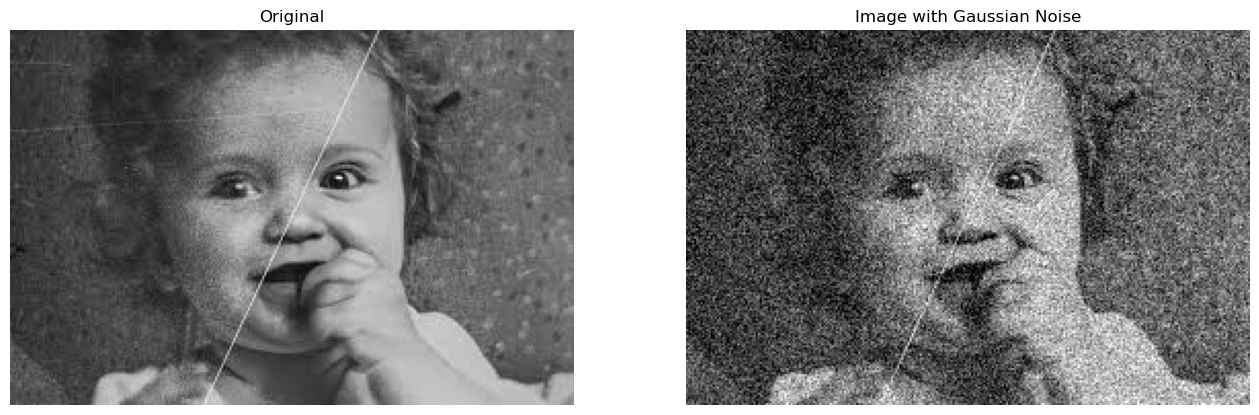

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, std=1):    
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


image = cv2.imread('images.jpeg', cv2.IMREAD_GRAYSCALE)
noisy_image = add_gaussian_noise(image, mean=0, std=30)

plt.figure(figsize=(16,12))


plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.axis("off")
plt.title("Original")


plt.subplot(1,2,2)
plt.imshow(noisy_image, cmap='gray')
plt.axis("off")
plt.title("Image with Gaussian Noise")
plt.show()



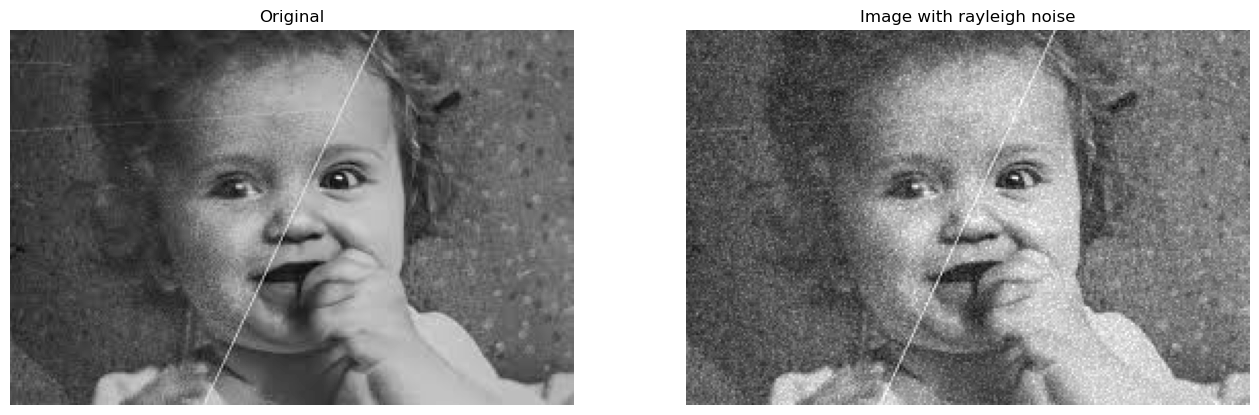

In [38]:
def add_rayleigh_noise(image, scale=1):
    rayleigh_noise = np.random.rayleigh(scale, image.shape)
    noisy_image = image + rayleigh_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image
    
image = cv2.imread('images.jpeg', cv2.IMREAD_GRAYSCALE)
noisy_image = add_rayleigh_noise(image, scale=20)

plt.figure(figsize=(16,12))


plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.axis("off")
plt.title("Original")


plt.subplot(1,2,2)
plt.imshow(noisy_image, cmap='gray')
plt.axis("off")
plt.title("Image with rayleigh noise")
plt.show()


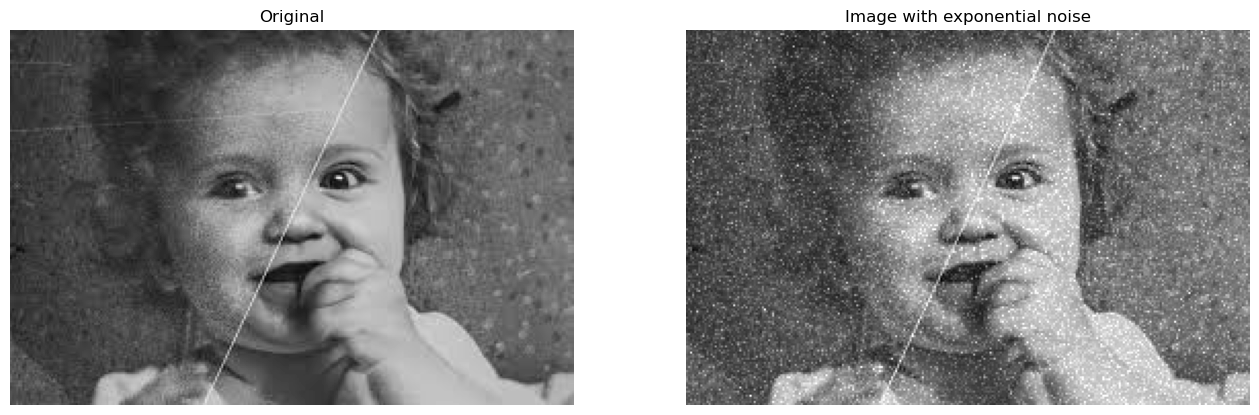

In [37]:
def add_exponential_noise(image, scale=1):
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


image = cv2.imread('images.jpeg', cv2.IMREAD_GRAYSCALE)
noisy_image = add_exponential_noise(image, scale=20)

plt.figure(figsize=(16,12))


plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.axis("off")
plt.title("Original")


plt.subplot(1,2,2)
plt.imshow(exponentioal, cmap='gray')
plt.axis("off")
plt.title("Image with exponential noise")
plt.show()

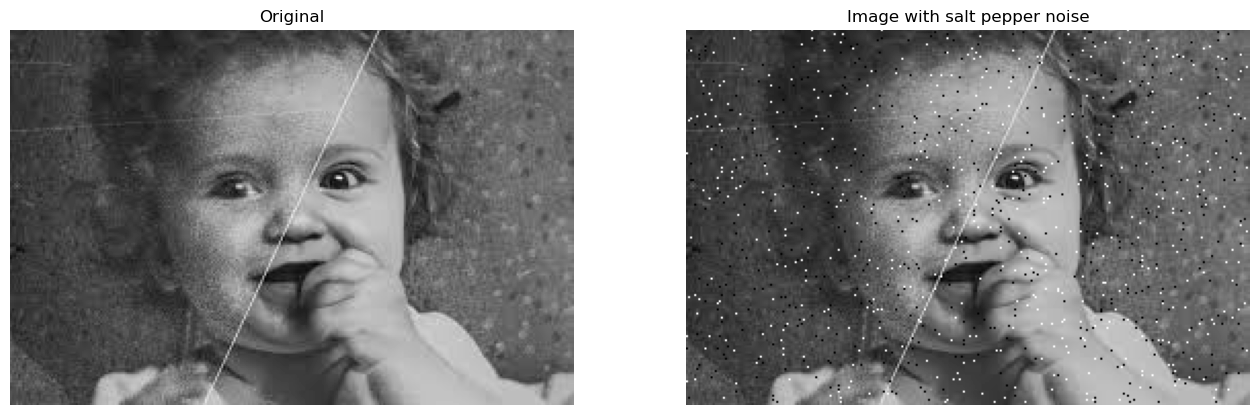

In [36]:
def add_salt_pepper_noise(image, salt_prob=0.05,pepper_prob=0.05):
    noisy_image = image.copy()
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1,
    int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1,
    int(num_pepper)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0
    return noisy_image

image = cv2.imread('images.jpeg', cv2.IMREAD_GRAYSCALE)
salt = add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01)

plt.figure(figsize=(16,12))


plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.axis("off")
plt.title("Original")


plt.subplot(1,2,2)
plt.imshow(salt, cmap='gray')
plt.axis("off")
plt.title("Image with salt pepper noise")
plt.show()

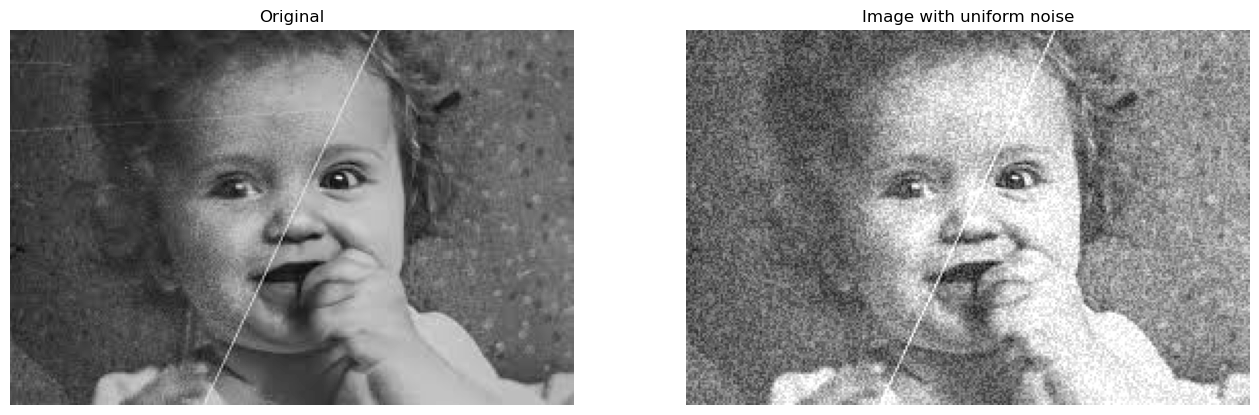

In [42]:
def add_uniform_noise(image, low=0, high=10):
    uniform_noise = np.random.uniform(low, high,image.shape)
    noisy_image = image + uniform_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image

image = cv2.imread('images.jpeg', cv2.IMREAD_GRAYSCALE)
uniform = add_uniform_noise(image, low=30, high=90)

plt.figure(figsize=(16,12))


plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.axis("off")
plt.title("Original")


plt.subplot(1,2,2)
plt.imshow(uniform, cmap='gray')
plt.axis("off")
plt.title("Image with uniform noise")
plt.show()


In [ ]:
def apply_box(image_input, box, filt_size):
    pad_size = int(np.floor(filt_size / 2))
    
    border pixels (mirror padding)
    image_padded = np.pad(image_input,pad_width=((pad_size,pad_size), (pad_size, pad_size)),mode='symmetric')
    
    
    image_box = copy.deepcopy(image_input)
    
    columns) of the original input image
    row, column = image_input.shape
    
    for i in range(row):
        for j in range(column):
        
            padded image based on the filter size
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            
            box filter element-wise
            results_box = box * patch_curr
            
            patch as the new pixel value
            image_box[i, j] = np.sum(results_box)
    return image_box